'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


D:\jupyterrrrr\AAAsindy批发\extrapolation_3d_error_summary.pdf
D:\jupyterrrrr\AAAsindy批发\extrapolation_3d_error_summary.png


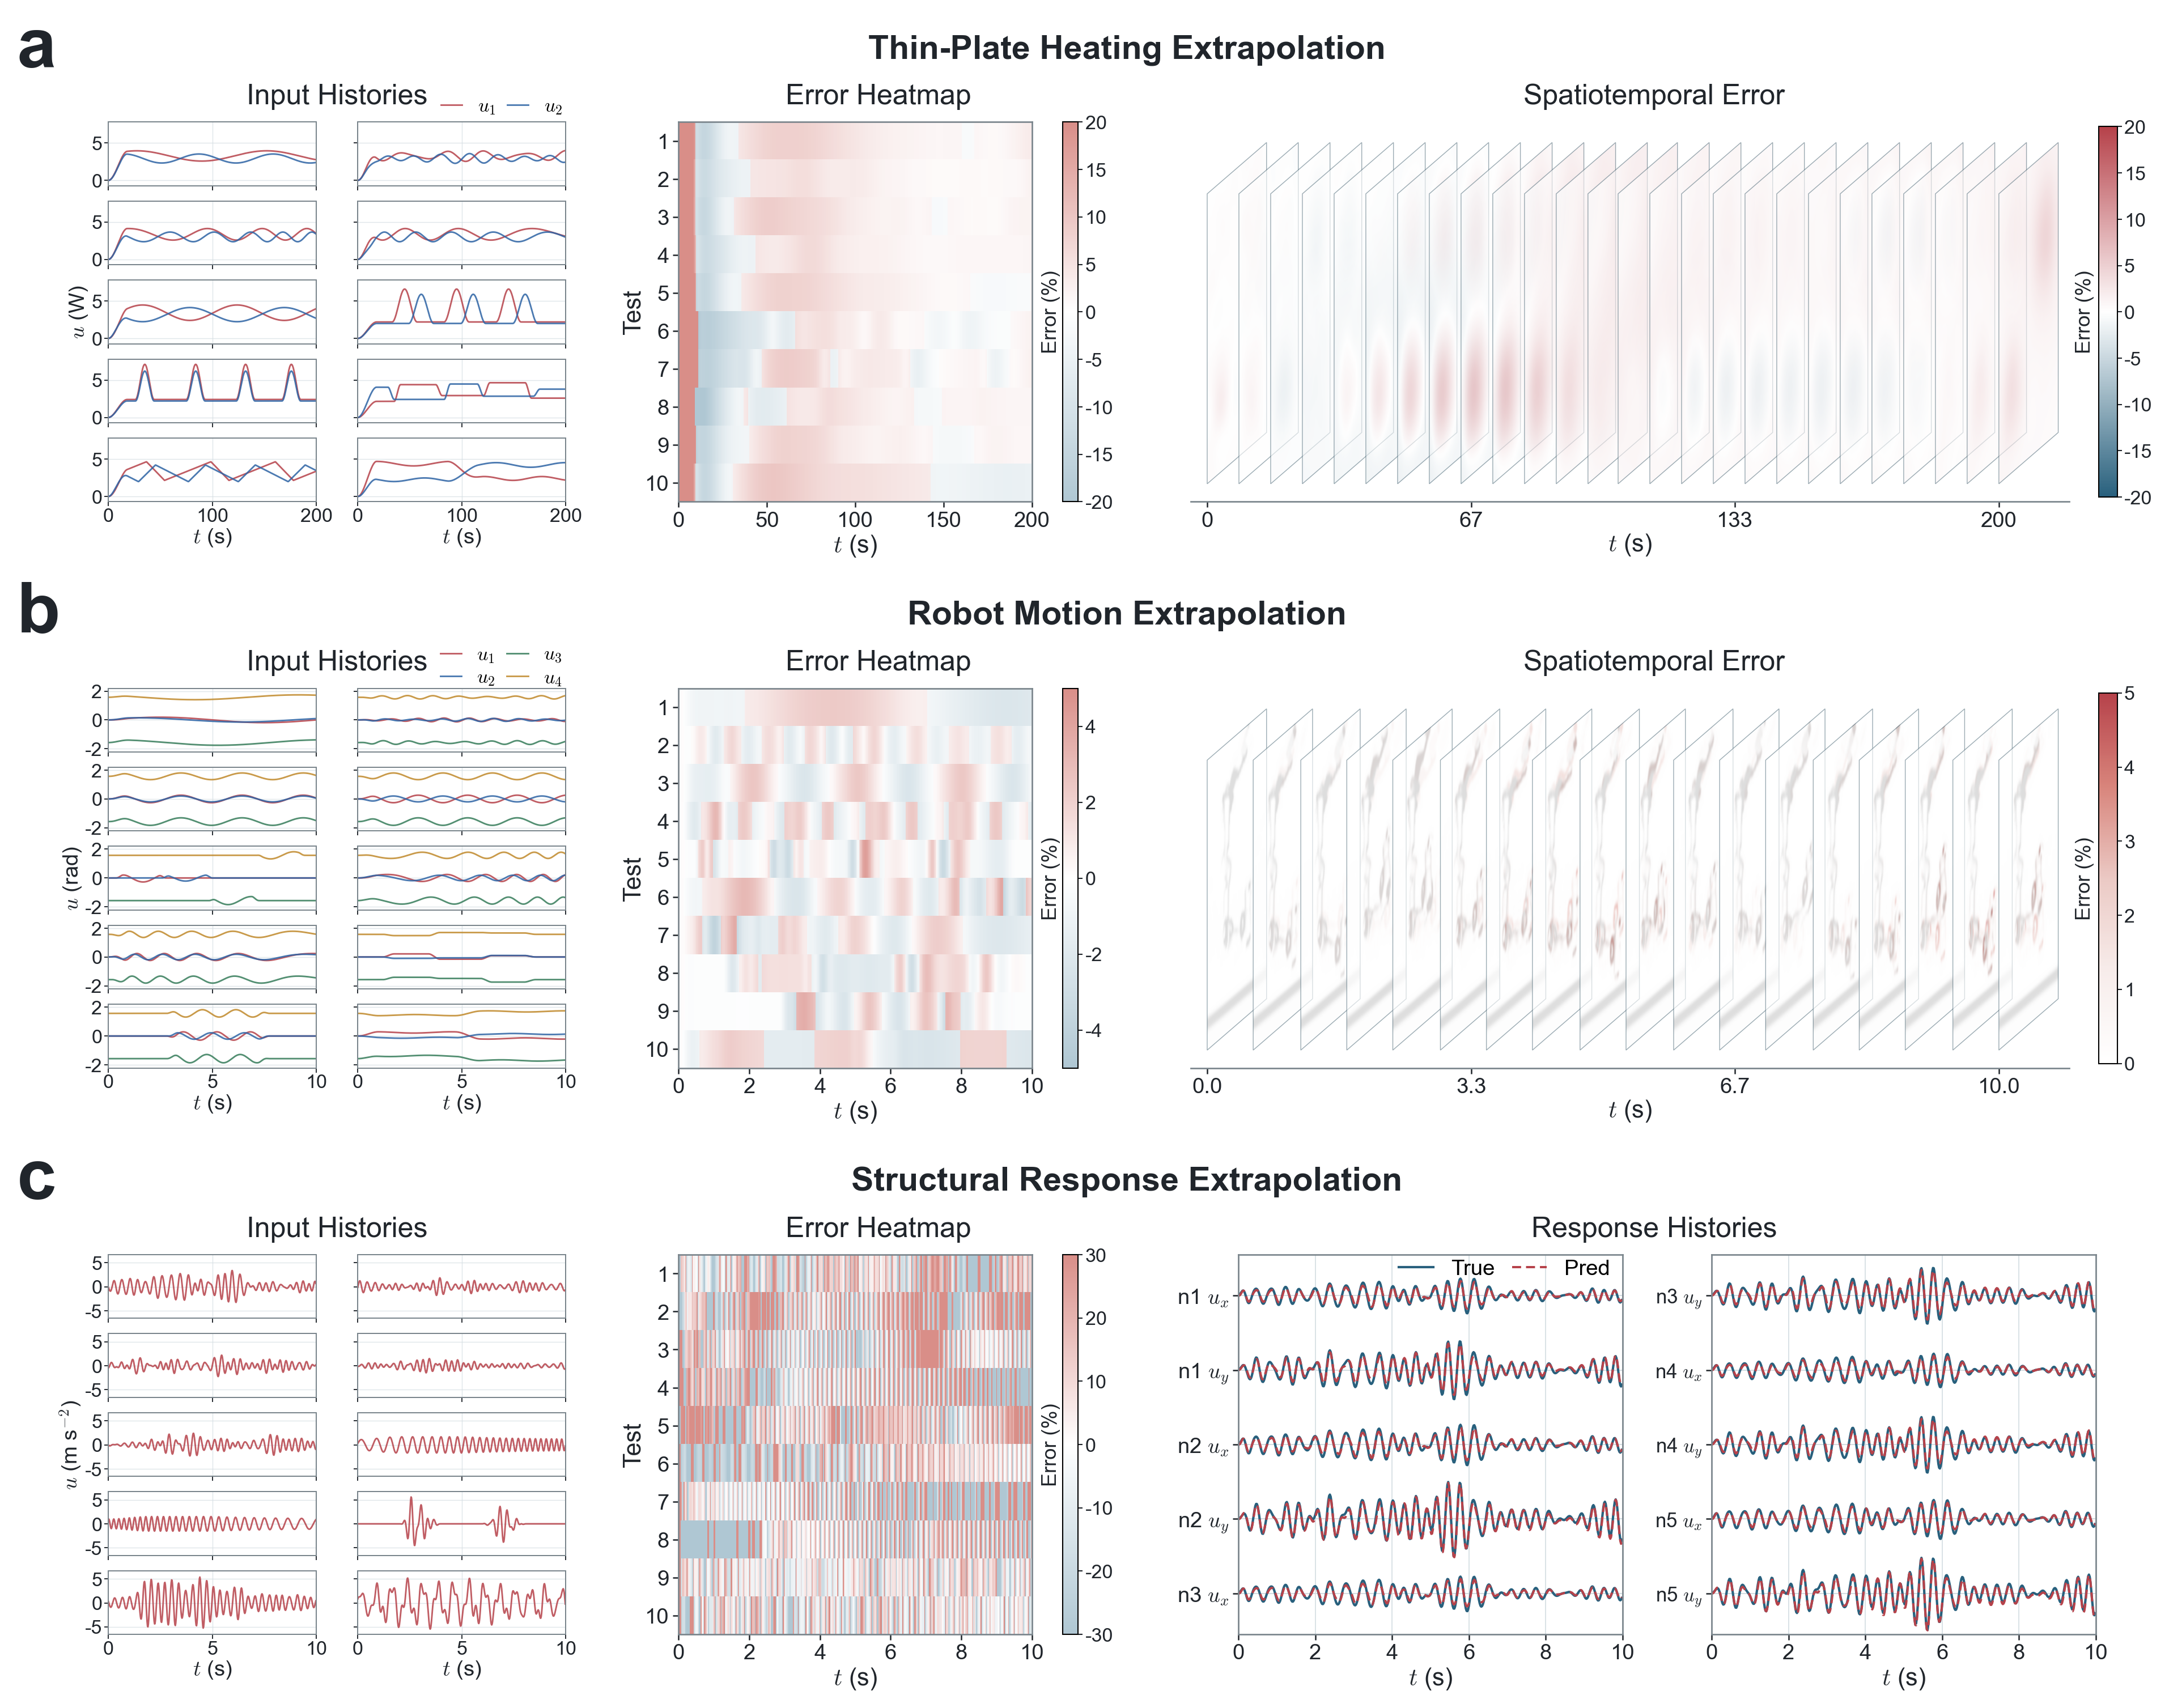

In [2]:
from __future__ import annotations

import json
import re
import sys
from pathlib import Path

import matplotlib as mpl

mpl.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.colors import LinearSegmentedColormap, Normalize, PowerNorm, TwoSlopeNorm
from matplotlib.patches import Polygon
from matplotlib.ticker import MaxNLocator
from matplotlib.transforms import Affine2D
from mpl_toolkits.axes_grid1 import make_axes_locatable
from PIL import Image, ImageDraw, ImageFilter
from scipy.ndimage import zoom
from scipy.optimize import least_squares

from plot_extrapolation_18panel_summary import (
    BASE_DIR,
    ACCENT_GOLD,
    ACCENT_GREEN,
    ACCENT_RED,
    ERROR_CMAP,
    FIGURE_MARGINS,
    GRID_COLOR,
    LABEL_SIZE,
    OUTPUT_DIR,
    ROW_LABEL_SIZE,
    SUBTITLE_SIZE,
    TEXT_COLOR,
    TICK_SIZE,
    TITLE_SIZE,
    TRACK_BLUE,
    configure_mpl,
    infer_square_grid,
    load_group,
    per_time_nrmse,
    PLATE_LX,
    PLATE_LY,
    representative_index,
)

PANDA_REF_DIR = Path(r"D:\FLARE\test files\panda")
if str(PANDA_REF_DIR) not in sys.path:
    sys.path.insert(0, str(PANDA_REF_DIR))
import render_panda_offline_comparison as panda_ref  # noqa: E402


PDF_PATH = OUTPUT_DIR / "extrapolation_3d_error_summary.pdf"
PNG_PATH = OUTPUT_DIR / "extrapolation_3d_error_summary.png"
CACHE_DIR = OUTPUT_DIR / "extrapolation_render_cache"
AGG_PARAMS = Path(
    r"C:\Users\HP\Desktop\test1+test2\AAAagg\outputs\tabular_window_sindy_2026_06_03_20_46_56_params.json"
)

FIGURE_SIZE = (12.8, 10.4)
PLOT_MARGINS = dict(FIGURE_MARGINS)
PLOT_MARGINS.update(left=0.052, right=0.975, top=0.942, bottom=0.055)
SPINE_COLOR = "#7A858C"
GRID_RGB = (0.83, 0.87, 0.89, 0.90)
STACK_FRAME_COUNT = 26
ROBOT_STACK_FRAME_COUNT = 18
STACK_IMAGE_SIZE = 84
STACK_SURFACE_ALPHA = 0.62
OBLIQUE_TIME_WIDTH = 8.8
OBLIQUE_SLICE_DX = 0.66
OBLIQUE_SLICE_DY = 0.40
OBLIQUE_SLICE_HEIGHT = 2.26
SIGNED_PERCENT_CMAP = LinearSegmentedColormap.from_list(
    "paper_signed_percent_error",
    [(0.00, "#28607D"), (0.50, "#FFFFFF"), (1.00, "#B6424A")],
)

POSITIVE_PERCENT_CMAP = LinearSegmentedColormap.from_list(
    "paper_positive_percent_error",
    [
        (0.00, "#AFC7D3"),
        (0.50, "#FFFFFF"),
        (1.00, "#D98E88"),
    ],
)
POSITIVE_PERCENT_CMAP1 = LinearSegmentedColormap.from_list(
    "paper_positive_percent_error_robot",
    ["#FFFFFF", "#F7ECEA", "#EBC9C4", "#D8847B", "#B6424A"],
)
FORCE_COLORS = [ACCENT_RED, "#2E64A5", ACCENT_GREEN, ACCENT_GOLD]
HEATMAP_LIMITS = {"sheet": 20.0, "robot": 5.0, "agg": 30.0}
TIME_LIMITS = {"sheet": (0.0, 200.0), "robot": (0.0, 10.0), "agg": (0.0, 10.0)}


def error_surface(sample: dict[str, np.ndarray], kind: str) -> tuple[np.ndarray, np.ndarray, str, str]:
    err = np.asarray(sample["p_pred"] - sample["p_true"], dtype=float)
    if kind == "sheet":
        z = np.abs(err)
        return sample["t"], z, "sensor", "temp. error"
    if kind == "robot":
        z = np.linalg.norm(err.reshape(err.shape[0], -1, 3), axis=2) * 1000.0
        return sample["t"], z, "marker", "error (mm)"
    if kind == "agg":
        z = np.abs(err) * 1000.0
        return sample["t"], z, "response", "error (mm)"
    raise ValueError(kind)


def per_time_signed_percent_error(samples: list[dict[str, np.ndarray]]) -> np.ndarray:
    rows = []
    for sample in samples:
        p_true = np.asarray(sample["p_true"], dtype=float)
        p_pred = np.asarray(sample["p_pred"], dtype=float)
        err = p_pred - p_true
        err_flat = err.reshape(err.shape[0], -1)
        true_flat = p_true.reshape(p_true.shape[0], -1)
        err_norm = np.linalg.norm(err_flat, axis=1)
        true_norm = np.linalg.norm(true_flat, axis=1)
        direction = np.sign(np.sum(err_flat * true_flat, axis=1))
        direction[direction == 0.0] = 1.0
        rows.append(100.0 * direction * err_norm / np.maximum(true_norm, 1e-12))
    return np.vstack(rows)


def style_3d_error_axis(ax, ylabel: str, zlabel: str, *, box_aspect=(3.2, 1.25, 0.78)) -> None:
    ax.view_init(elev=0, azim=-60)
    ax.set_proj_type("ortho")
    ax.set_box_aspect(box_aspect, zoom=1.28)
    ax.set_anchor("W")
    ax.set_xlabel(r"$t$ (s)", fontsize=LABEL_SIZE, labelpad=2)
    ax.set_ylabel(ylabel, fontsize=LABEL_SIZE, labelpad=-5)
    ax.set_zlabel(zlabel, fontsize=LABEL_SIZE, labelpad=-5)
    ax.tick_params(axis="both", labelsize=TICK_SIZE, colors=TEXT_COLOR, pad=-2)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.zaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.xaxis.pane.set_facecolor((1, 1, 1, 0))
    ax.yaxis.pane.set_facecolor((1, 1, 1, 0))
    ax.zaxis.pane.set_facecolor((1, 1, 1, 0))
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis._axinfo["grid"]["color"] = GRID_RGB
        axis._axinfo["grid"]["linewidth"] = 0.45
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.line.set_color(SPINE_COLOR)
        axis.line.set_linewidth(0.7)


def stack_frame_indices(length: int, count: int = STACK_FRAME_COUNT) -> np.ndarray:
    return np.unique(np.linspace(0, length - 1, min(length, count)).round().astype(int))


def upsample_image(values: np.ndarray, size: int = STACK_IMAGE_SIZE) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    factor_y = size / values.shape[0]
    factor_x = size / values.shape[1]
    enlarged = zoom(values, (factor_y, factor_x), order=3)
    if enlarged.shape != (size, size):
        pil = Image.fromarray(enlarged.astype(np.float32), mode="F")
        enlarged = np.asarray(pil.resize((size, size), Image.Resampling.BICUBIC), dtype=float)
    return enlarged


def style_compact_axis(ax: plt.Axes, grid: bool = True) -> None:
    ax.tick_params(axis="both", labelsize=TICK_SIZE-1, length=1.8, width=0.45, colors=TEXT_COLOR, pad=0.8)
    for spine in ax.spines.values():
        spine.set_linewidth(0.48)
        spine.set_color(SPINE_COLOR)
    if grid:
        ax.grid(True, color=GRID_COLOR, linewidth=0.35, alpha=0.70)


def style_axis(ax: plt.Axes, grid: bool = True) -> None:
    ax.tick_params(axis="both", labelsize=TICK_SIZE, length=2.5, width=0.6, colors=TEXT_COLOR, pad=1.5)
    for spine in ax.spines.values():
        spine.set_linewidth(0.65)
        spine.set_color(SPINE_COLOR)
    if grid:
        ax.grid(True, color=GRID_COLOR, linewidth=0.48, alpha=0.85)


def shrink_axis_width(ax: plt.Axes, factor: float = 0.90) -> None:
    pos = ax.get_position()
    new_width = pos.width * factor
    ax.set_position([pos.x0 + 0.5 * (pos.width - new_width), pos.y0, new_width, pos.height])


def shift_axis(ax: plt.Axes, dx: float = 0.0, dy: float = 0.0) -> None:
    pos = ax.get_position()
    ax.set_position([pos.x0 + dx, pos.y0 + dy, pos.width, pos.height])


def add_column_title(fig: plt.Figure, subplot_spec, title: str) -> None:
    ax = fig.add_subplot(subplot_spec)
    ax.axis("off")
    ax.text(
        0.5,
        0.12,
        title,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=SUBTITLE_SIZE + 0.8,
        fontweight="normal",
        color=TEXT_COLOR,
    )


def draw_input_histories(
    fig: plt.Figure,
    subplot_spec,
    samples: list[dict[str, np.ndarray]],
    ylabel: str,
    xlim: tuple[float, float],
    legend_labels: list[str],
    legend_ncol: int,
    legend_y: float | None,
) -> None:
    grid = GridSpecFromSubplotSpec(5, 2, subplot_spec=subplot_spec, hspace=0.24, wspace=0.20)
    all_u = []
    for sample in samples:
        u = np.asarray(sample["forcing_raw"], dtype=float)
        if u.ndim == 1:
            u = u[:, None]
        all_u.append(u)
    finite = np.concatenate([u.ravel() for u in all_u if u.size])
    y_min, y_max = float(np.nanmin(finite)), float(np.nanmax(finite))
    pad = max(1e-9, 0.10 * (y_max - y_min))

    for idx, sample in enumerate(samples):
        ax = fig.add_subplot(grid[idx // 2, idx % 2])
        t = np.asarray(sample["t"], dtype=float)
        u = np.asarray(sample["forcing_raw"], dtype=float)
        if u.ndim == 1:
            u = u[:, None]
        for j in range(u.shape[1]):
            label = legend_labels[j] if legend_y is not None and idx == 1 and j < len(legend_labels) else None
            ax.plot(t, u[:, j], color=FORCE_COLORS[j % len(FORCE_COLORS)], lw=0.68, alpha=0.86, label=label)
        ax.set_xlim(*xlim)
        ax.set_ylim(y_min - pad, y_max + pad)
        style_compact_axis(ax)
        if legend_y is not None and idx == 1:
            ax.legend(
                loc="upper right",
                bbox_to_anchor=(1.02, legend_y),
                frameon=False,
                fontsize=TICK_SIZE - 1,
                handlelength=1.1,
                borderaxespad=0.0,
                ncol=legend_ncol,
                columnspacing=0.6,
                labelspacing=0.25,
            )
        if idx % 2 == 0 and idx // 2 == 2:
            ax.set_ylabel(ylabel, fontsize=TICK_SIZE, labelpad=0.8)
        elif idx % 2 == 1:
            ax.set_yticklabels([])
        if idx // 2 == 4:
            ax.set_xlabel(r"$t$ (s)", fontsize=TICK_SIZE, labelpad=0.4)
        else:
            ax.set_xticklabels([])


def draw_error_heatmap(
    fig: plt.Figure,
    ax: plt.Axes,
    t: np.ndarray,
    errors: np.ndarray,
    *,
    vmax: float,
    xlim: tuple[float, float],
) -> None:
    image = ax.imshow(
        errors,
        aspect="auto",
        origin="upper",
        extent=(float(t[0]), float(t[-1]), 10.5, 0.5),
        cmap=POSITIVE_PERCENT_CMAP,
        vmin=-vmax,
        vmax=vmax,
        interpolation="nearest",
    )
    ax.set_xlim(*xlim)
    ax.set_ylim(10.5, 0.5)
    ax.set_xlabel(r"$t$ (s)", fontsize=LABEL_SIZE, labelpad=1)
    ax.set_ylabel("Test", fontsize=LABEL_SIZE, labelpad=0)
    ax.set_yticks(np.arange(1, 11))
    ax.set_yticklabels([str(i) for i in range(1, 11)])
    style_axis(ax, grid=False)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4.4%", pad=0.180)
    cbar = fig.colorbar(image, cax=cax)
    cbar.ax.tick_params(labelsize=TICK_SIZE - 1, length=2, width=0.5, pad=1)
    cbar.outline.set_linewidth(0.5)
    cbar.ax.yaxis.set_ticks_position("right")
    cbar.ax.yaxis.set_label_position("left")
    cbar.set_label("Error (%)", fontsize=TICK_SIZE - 0.5, labelpad=1)


def response_channel_labels(count: int) -> list[str]:
    return [f"n{i // 2 + 1} " + (r"$u_x$" if i % 2 == 0 else r"$u_y$") for i in range(count)]


def draw_agg_residual_histories(ax: plt.Axes, sample: dict[str, np.ndarray], count: int = 5) -> None:
    t = np.asarray(sample["t"], dtype=float)
    residual = 1000.0 * (np.asarray(sample["p_pred"], dtype=float)[:, :count] - np.asarray(sample["p_true"], dtype=float)[:, :count])
    amp = max(float(np.nanpercentile(np.abs(residual), 99.0)), 1e-9)
    spacing = 3.0 * amp
    offsets = spacing * np.arange(count - 1, -1, -1, dtype=float)
    labels = response_channel_labels(count)

    for j in range(count):
        ax.plot(t, residual[:, j] + offsets[j], color=ACCENT_RED, lw=1.05)
        ax.axhline(offsets[j], color="#D7DEE2", lw=0.48, zorder=0)
    ax.set_xlim(*TIME_LIMITS["agg"])
    ax.set_ylim(offsets[-1] - 1.65 * amp, offsets[0] + 1.65 * amp)
    ax.set_yticks(offsets)
    ax.set_yticklabels(labels, fontsize=TICK_SIZE - 0.8)
    ax.set_xlabel(r"$t$ (s)", fontsize=LABEL_SIZE, labelpad=1)
    ax.set_ylabel("Residual (mm)", fontsize=LABEL_SIZE, labelpad=1)
    style_axis(ax)


def draw_agg_response_group(
    ax: plt.Axes,
    sample: dict[str, np.ndarray],
    start: int,
    count: int,
    *,
    legend: bool = False,
) -> None:
    t = np.asarray(sample["t"], dtype=float)
    true = 1000.0 * np.asarray(sample["p_true"], dtype=float)[:, start : start + count]
    pred = 1000.0 * np.asarray(sample["p_pred"], dtype=float)[:, start : start + count]
    amp = max(float(np.nanpercentile(np.abs(np.concatenate([true, pred], axis=0)), 99.0)), 1e-9)
    spacing = 3.0 * amp
    offsets = spacing * np.arange(count - 1, -1, -1, dtype=float)
    labels = response_channel_labels(start + count)[start : start + count]

    for j in range(count):
        ax.plot(t, true[:, j] + offsets[j], color=TRACK_BLUE, lw=1.00, label="True" if j == 0 else None)
        ax.plot(
            t,
            pred[:, j] + offsets[j],
            color=ACCENT_RED,
            lw=0.95,
            ls=(0, (4.0, 2.2)),
            label="Pred" if j == 0 else None,
        )
        ax.axhline(offsets[j], color="#D7DEE2", lw=0.45, zorder=0)
    ax.set_xlim(*TIME_LIMITS["agg"])
    ax.set_ylim(offsets[-1] - 1.65 * amp, offsets[0] + 1.65 * amp)
    ax.set_yticks(offsets)
    ax.set_yticklabels(labels, fontsize=TICK_SIZE - 1)
    ax.set_xlabel(r"$t$ (s)", fontsize=LABEL_SIZE, labelpad=1)
    ax.set_ylabel("")
    style_axis(ax)
    if legend:
        ax.legend(
            loc="upper right",
            bbox_to_anchor=(0.99, 1.01),
            frameon=False,
            fontsize=TICK_SIZE,
            handlelength=1.6,
            borderaxespad=0.0,
            ncol=2,
            columnspacing=0.8,
        )


def draw_agg_response_histories(fig: plt.Figure, subplot_spec, sample: dict[str, np.ndarray]) -> None:
    grid = GridSpecFromSubplotSpec(1, 2, subplot_spec=subplot_spec, wspace=0.17)
    ax_left = fig.add_subplot(grid[0, 0])
    ax_right = fig.add_subplot(grid[0, 1])
    draw_agg_response_group(ax_left, sample, 0, 5, legend=True)
    draw_agg_response_group(ax_right, sample, 5, 5, legend=False)
    ax_right.set_yticklabels(response_channel_labels(10)[5:10], fontsize=TICK_SIZE - 0.8)
    shrink_axis_width(ax_left, 0.90)
    shrink_axis_width(ax_right, 0.90)
    shift_axis(ax_left, dx=0.012)


def draw_rendered_stack_axis(
    fig: plt.Figure,
    ax,
    t: np.ndarray,
    frames: np.ndarray,
    image_stack: np.ndarray,
    *,
    title: str,
    cmap,
    norm,
    cbar_label: str,
    background_stack: np.ndarray | None = None,
    y_label: str = "image x",
    z_label: str = "image y",
    y_extent: tuple[float, float] = (0.0, 1.0),
    z_extent: tuple[float, float] = (0.0, 1.0),
) -> None:
    t0, t1 = float(t[0]), float(t[-1])
    denom = max(t1 - t0, 1e-12)
    y0 = 0.0
    for order, (frame_id, img) in enumerate(zip(frames, image_stack)):
        x0 = OBLIQUE_TIME_WIDTH * (float(t[frame_id]) - t0) / denom
        transform = (
            Affine2D()
            .from_values(OBLIQUE_SLICE_DX, OBLIQUE_SLICE_DY, 0.0, OBLIQUE_SLICE_HEIGHT, x0, y0)
            + ax.transData
        )
        if background_stack is not None:
            ax.imshow(
                background_stack[order],
                origin="lower",
                extent=(0.0, 1.0, 0.0, 1.0),
                cmap="Greys",
                vmin=0.0,
                vmax=1.0,
                interpolation="bicubic",
                alpha=0.34,
                transform=transform,
                zorder=1 + order,
                clip_on=True,
                rasterized=True,
            )
        ax.imshow(
            img,
            origin="lower",
            extent=(0.0, 1.0, 0.0, 1.0),
            cmap=cmap,
            norm=norm,
            interpolation="bicubic",
            alpha=STACK_SURFACE_ALPHA,
            transform=transform,
            zorder=2 + order,
            clip_on=True,
            rasterized=True,
        )
        corners = np.asarray(
            [
                [x0, y0],
                [x0 + OBLIQUE_SLICE_DX, y0 + OBLIQUE_SLICE_DY],
                [x0 + OBLIQUE_SLICE_DX, y0 + OBLIQUE_SLICE_DY + OBLIQUE_SLICE_HEIGHT],
                [x0, y0 + OBLIQUE_SLICE_HEIGHT],
            ]
        )
        ax.add_patch(
            Polygon(
                corners,
                closed=True,
                facecolor="none",
                edgecolor="#26495A",
                linewidth=0.34,
                alpha=0.45,
                zorder=3 + order,
            )
        )

    xtick_values = np.linspace(t0, t1, 4)
    xtick_positions = OBLIQUE_TIME_WIDTH * (xtick_values - t0) / denom
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels([f"{v:.0f}" if t1 > 20 else f"{v:.1f}" for v in xtick_values])
    ax.set_xlim(-0.18, OBLIQUE_TIME_WIDTH + OBLIQUE_SLICE_DX + 0.12)
    ax.set_ylim(-0.14, OBLIQUE_SLICE_HEIGHT + OBLIQUE_SLICE_DY + 0.16)
    ax.set_aspect("auto")
    ax.set_xlabel(r"$t$ (s)", fontsize=LABEL_SIZE, labelpad=0.5)
    ax.set_yticks([])
    ax.grid(False)
    ax.set_facecolor("white")
    for side, spine in ax.spines.items():
        spine.set_visible(side == "bottom")
        spine.set_linewidth(0.65)
        spine.set_color(SPINE_COLOR)
    ax.tick_params(axis="x", labelsize=TICK_SIZE, colors=TEXT_COLOR, length=2.5, width=0.6, pad=1.5)

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.020, pad=0.032)
    cbar.ax.tick_params(labelsize=TICK_SIZE - 1, length=2, width=0.5, pad=1)
    cbar.ax.yaxis.get_offset_text().set_fontsize(TICK_SIZE - 1)
    cbar.outline.set_linewidth(0.5)
    
    cbar.ax.yaxis.set_ticks_position("right")
    cbar.ax.yaxis.set_label_position("left")
    cbar.set_label(cbar_label, fontsize=TICK_SIZE - 0.5, labelpad=2)


def draw_sheet_rendered_error_stack(
    fig: plt.Figure,
    ax,
    sample: dict[str, np.ndarray],
    rep_idx: int,
) -> None:
    t = np.asarray(sample["t"], dtype=float)
    frames = stack_frame_indices(len(t), STACK_FRAME_COUNT)
    p_true = np.asarray(sample["p_true"], dtype=float)
    p_pred = np.asarray(sample["p_pred"], dtype=float)
    field_range = max(float(np.nanpercentile(p_true, 99.5) - np.nanpercentile(p_true, 0.5)), 1e-12)
    diff = 100.0 * (p_pred - p_true) / field_range
    ny, nx = infer_square_grid(diff.shape[1])
    image_stack = np.stack(
        [upsample_image(diff[i].reshape(ny, nx), STACK_IMAGE_SIZE) for i in frames],
        axis=0,
    )
    vmax = 20.0
    draw_rendered_stack_axis(
        fig,
        ax,
        t,
        frames,
        image_stack,
        title=f"Rendered Error Stack, Test {rep_idx + 1}",
        cmap=SIGNED_PERCENT_CMAP,
        norm=TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax),
        cbar_label="Error (%)",
        y_label="plate x (m)",
        z_label="plate y (m)",
        y_extent=(0.0, PLATE_LX),
        z_extent=(0.0, PLATE_LY),
    )


def load_dict_npy(path: Path) -> dict:
    obj = np.load(path, allow_pickle=True)
    if isinstance(obj, np.ndarray) and obj.shape == ():
        return obj.item()
    raise ValueError(f"Expected dict-style .npy file, got {path}")


def sample_path(sample: dict[str, np.ndarray]) -> Path:
    value = sample["path"]
    if isinstance(value, np.ndarray):
        value = value.item()
    return Path(str(value))


def extrapolation_index(path: Path) -> int:
    match = re.search(r"(\d{3})$", path.stem)
    if not match:
        raise ValueError(f"Cannot infer extrapolation index from {path.name}")
    return int(match.group(1))


def marker_world_coordinates(model, data, body_ids: list[int], local_markers: np.ndarray, qpos: np.ndarray) -> np.ndarray:
    data.qpos[:] = qpos
    data.qvel[:] = 0.0
    panda_ref.mujoco.mj_forward(model, data)
    coords = []
    for body_id in body_ids:
        pos = data.xpos[body_id].copy()
        rot = data.xmat[body_id].reshape(3, 3).copy()
        coords.append((pos[None, :] + local_markers @ rot.T).reshape(-1))
    return np.concatenate(coords, axis=0)


def fit_q_to_markers(model, data, body_ids: list[int], local_markers: np.ndarray, target_markers: np.ndarray, initial_q: np.ndarray) -> tuple[np.ndarray, float]:
    lower = model.jnt_range[:, 0].astype(float)
    upper = model.jnt_range[:, 1].astype(float)
    initial_q = np.clip(np.asarray(initial_q, dtype=float), lower + 1e-5, upper - 1e-5)
    target = np.asarray(target_markers, dtype=float).reshape(-1)

    def residual(q: np.ndarray) -> np.ndarray:
        return marker_world_coordinates(model, data, body_ids, local_markers, q) - target

    result = least_squares(
        residual,
        initial_q,
        bounds=(lower, upper),
        method="trf",
        max_nfev=100,
        ftol=1e-8,
        xtol=1e-8,
        gtol=1e-8,
    )
    return result.x.astype(float), float(np.sqrt(np.mean(result.fun**2)))


def fixed_crop_images(images: list[np.ndarray], out_size: int = STACK_IMAGE_SIZE) -> list[np.ndarray]:
    h, w = images[0].shape[:2]
    union = np.zeros((h, w), dtype=bool)
    yy = np.arange(h)[:, None]
    for image in images:
        gray = np.asarray(image, dtype=float).mean(axis=2)
        union |= (gray < 235.0) & (yy > 0.14 * h)
    ys, xs = np.where(union)
    if xs.size == 0 or ys.size == 0:
        return [np.asarray(Image.fromarray(img).resize((out_size, out_size), Image.Resampling.LANCZOS)) for img in images]
    x0, x1 = int(xs.min()), int(xs.max())
    y0, y1 = int(ys.min()), int(ys.max())
    cx, cy = 0.5 * (x0 + x1), 0.5 * (y0 + y1)
    side = int(max(x1 - x0, y1 - y0) * 1.14)
    side = max(side, int(0.34 * min(h, w)))
    side = min(side, min(h, w))
    left = int(np.clip(cx - 0.5 * side, 0, w - side))
    top = int(np.clip(cy - 0.5 * side, 0, h - side))
    cropped = []
    for image in images:
        tile = np.asarray(image[top : top + side, left : left + side], dtype=np.uint8)
        pil = Image.fromarray(tile)
        pil = pil.filter(ImageFilter.UnsharpMask(radius=0.8, percent=160, threshold=2))
        cropped.append(np.asarray(pil.resize((out_size, out_size), Image.Resampling.LANCZOS)))
    return cropped


def robot_q_cache_path(offline_path: Path, frames: np.ndarray) -> Path:
    signature = "_".join(str(int(v)) for v in frames)
    return CACHE_DIR / f"{offline_path.stem}_qfit_{len(frames)}_{abs(hash(signature)) % 1000000:06d}.npz"


def render_robot_error_images(sample: dict[str, np.ndarray], frames: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    offline_path = sample_path(sample)
    test_idx = extrapolation_index(offline_path)
    true_file = panda_ref.DATASET_ROOT / "test" / f"panda_test_traj_{test_idx:03d}.npy"
    true_sample = load_dict_npy(true_file)
    true_q = np.asarray(true_sample["q"], dtype=float)
    link_names = [str(v) for v in true_sample["link_names"]]
    local_markers = np.asarray(true_sample["local_markers"], dtype=float)

    scene_xml = panda_ref.write_render_scene_xml()
    xml_text = scene_xml.read_text(encoding="utf-8")
    if "offwidth" not in xml_text:
        xml_text = xml_text.replace(
            '<global azimuth="135" elevation="-25"/>',
            '<global azimuth="135" elevation="-25" offwidth="1600" offheight="1600"/>',
        )
        scene_xml.write_text(xml_text, encoding="utf-8")

    model = panda_ref.mujoco.MjModel.from_xml_path(str(scene_xml))
    fit_data = panda_ref.mujoco.MjData(model)
    body_ids = [
        panda_ref.mujoco.mj_name2id(model, panda_ref.mujoco.mjtObj.mjOBJ_BODY, name)
        for name in link_names
    ]
    if any(body_id < 0 for body_id in body_ids):
        raise ValueError("One or more Panda link names were not found in the MuJoCo model.")

    cache_path = robot_q_cache_path(offline_path, frames)
    if cache_path.exists():
        cache = np.load(cache_path)
        q_pred = np.asarray(cache["q_pred"], dtype=float)
    else:
        p_pred = np.asarray(sample["p_pred"], dtype=float)
        q_pred_list = []
        rmse_list = []
        for frame_idx in frames:
            q_fit, rmse = fit_q_to_markers(
                model,
                fit_data,
                body_ids,
                local_markers,
                p_pred[int(frame_idx)],
                true_q[int(frame_idx)],
            )
            q_pred_list.append(q_fit)
            rmse_list.append(rmse)
        q_pred = np.stack(q_pred_list, axis=0)
        np.savez_compressed(
            cache_path,
            frames=np.asarray(frames, dtype=int),
            q_pred=q_pred,
            fit_rmse=np.asarray(rmse_list, dtype=float),
        )

    render_data_true = panda_ref.mujoco.MjData(model)
    render_data_pred = panda_ref.mujoco.MjData(model)
    renderer = panda_ref.mujoco.Renderer(model, height=900, width=900)
    camera = panda_ref.make_camera()
    camera.lookat[:] = [0.34, -0.02, 0.52]
    camera.distance = 1.30
    camera.azimuth = 134.0
    camera.elevation = -20.0
    option = panda_ref.make_scene_option()

    true_images = []
    pred_images = []
    for k, frame_idx in enumerate(frames):
        true_images.append(panda_ref.render_robot(model, render_data_true, renderer, camera, option, true_q[int(frame_idx)]))
        pred_images.append(panda_ref.render_robot(model, render_data_pred, renderer, camera, option, q_pred[k]))
    all_cropped = fixed_crop_images(true_images + pred_images, STACK_IMAGE_SIZE)
    true_cropped = all_cropped[: len(frames)]
    pred_cropped = all_cropped[len(frames) :]

    p_true = np.asarray(sample["p_true"], dtype=float)
    p_pred = np.asarray(sample["p_pred"], dtype=float)
    err_norm = np.linalg.norm(p_pred - p_true, axis=1)
    scale = max(float(np.linalg.norm(p_true)) / np.sqrt(max(p_true.shape[0], 1)), 1e-12)
    frame_nrmse = 100.0 * err_norm / scale

    diff_images = []
    background_images = []
    for frame_idx, true_img, pred_img in zip(frames, true_cropped, pred_cropped):
        raw = np.linalg.norm(pred_img.astype(float) - true_img.astype(float), axis=2)
        active = raw[raw > 1.0]
        raw_scale = max(float(np.nanpercentile(active, 95.0)) if active.size else 1.0, 1e-12)
        diff = raw / raw_scale * float(frame_nrmse[int(frame_idx)])
        diff_images.append(diff)
        gray = true_img.astype(float).mean(axis=2) / 255.0
        mask = np.clip((0.94 - gray) / 0.42, 0.0, 1.0)
        background_images.append(mask)
    return np.stack(diff_images, axis=0), np.stack(background_images, axis=0)


def draw_robot_rendered_error_stack(fig: plt.Figure, ax, sample: dict[str, np.ndarray], rep_idx: int) -> None:
    t = np.asarray(sample["t"], dtype=float)
    frames = stack_frame_indices(len(t), ROBOT_STACK_FRAME_COUNT)
    image_stack, background_stack = render_robot_error_images(sample, frames)
    vmax = max(float(np.nanpercentile(image_stack, 99.0)), 0.5)
    draw_rendered_stack_axis(
        fig,
        ax,
        t,
        frames,
        image_stack,
        title=f"Rendered Error Stack, Test {rep_idx + 1}",
        cmap=POSITIVE_PERCENT_CMAP1,
        norm=Normalize(vmin=0.0, vmax=HEATMAP_LIMITS["robot"]),
        cbar_label="Error (%)",
        background_stack=background_stack,
    )


def agg_sensor_order() -> tuple[np.ndarray, np.ndarray]:
    if AGG_PARAMS.exists():
        params = json.loads(AGG_PARAMS.read_text(encoding="utf-8"))
        names = [str(v) for v in params["sensor_names"]]
    else:
        names = [f"node{i:02d}_{comp}" for i in range(1, 19) for comp in ("ux", "uy")]
    ux_cols = []
    uy_cols = []
    for i, name in enumerate(names):
        if name.endswith("_ux"):
            ux_cols.append(i)
        elif name.endswith("_uy"):
            uy_cols.append(i)
    return np.asarray(ux_cols, dtype=int), np.asarray(uy_cols, dtype=int)


def frame_geometry() -> tuple[np.ndarray, list[tuple[int, int]]]:
    lx, ly, lz = 7.50, 5.00, 3.20
    coords = np.asarray(
        [
            [0, 0, 0],
            [lx, 0, 0],
            [2 * lx, 0, 0],
            [2 * lx, ly, 0],
            [lx, ly, 0],
            [0, ly, 0],
            [0, 0, lz],
            [lx, 0, lz],
            [2 * lx, 0, lz],
            [2 * lx, ly, lz],
            [lx, ly, lz],
            [0, ly, lz],
            [0, 0, 2 * lz],
            [lx, 0, 2 * lz],
            [2 * lx, 0, 2 * lz],
            [2 * lx, ly, 2 * lz],
            [lx, ly, 2 * lz],
            [0, ly, 2 * lz],
        ],
        dtype=float,
    )
    edges: list[tuple[int, int]] = []
    for base in (0, 6, 12):
        edges += [(base + 0, base + 1), (base + 1, base + 2)]
        edges += [(base + 5, base + 4), (base + 4, base + 3)]
        edges += [(base + 0, base + 5), (base + 1, base + 4), (base + 2, base + 3)]
    for lower in (0, 6):
        for i in range(6):
            edges.append((lower + i, lower + i + 6))
    return coords, edges


def project_frame(coords: np.ndarray) -> np.ndarray:
    return np.column_stack([coords[:, 0] + 0.36 * coords[:, 1], coords[:, 2] + 0.18 * coords[:, 1]])


def draw_structure_raster(draw: ImageDraw.ImageDraw, xy: np.ndarray, edges: list[tuple[int, int]], color: tuple[int, int, int], width: int) -> None:
    for i, j in edges:
        draw.line([tuple(xy[i]), tuple(xy[j])], fill=color, width=width, joint="curve")
    r = max(2, width)
    for x, y in xy:
        draw.ellipse((x - r, y - r, x + r, y + r), fill=color)


def structure_image_from_displacement(disp_xy: np.ndarray, *, scale: float = 45.0, size: int = STACK_IMAGE_SIZE) -> np.ndarray:
    coords, edges = frame_geometry()
    base = project_frame(coords)
    deformed = coords.copy()
    deformed[:, 0] += scale * disp_xy[:, 0]
    deformed[:, 1] += scale * disp_xy[:, 1]
    def_xy = project_frame(deformed)
    all_xy = np.vstack([base, def_xy])
    mins = all_xy.min(axis=0)
    maxs = all_xy.max(axis=0)
    span = max(float(np.max(maxs - mins)), 1e-9)
    margin = 0.12 * span
    xy = (def_xy - (mins - margin)) / (span + 2.0 * margin)
    px = np.empty_like(xy)
    px[:, 0] = xy[:, 0] * (size - 1)
    px[:, 1] = (1.0 - xy[:, 1]) * (size - 1)
    image = Image.new("RGB", (size, size), (248, 249, 247))
    drawer = ImageDraw.Draw(image)
    draw_structure_raster(drawer, px, edges, (36, 85, 112), max(2, int(size / 42)))
    return np.asarray(image, dtype=np.uint8)


def normalized_frame_projection() -> tuple[np.ndarray, list[tuple[int, int]]]:
    coords, edges = frame_geometry()
    xy = project_frame(coords)
    mins = xy.min(axis=0)
    maxs = xy.max(axis=0)
    span = max(float(np.max(maxs - mins)), 1e-9)
    margin = 0.12 * span
    xy_norm = (xy - (mins - margin)) / (span + 2.0 * margin)
    return xy_norm, edges


def structure_error_field(error_mm: np.ndarray, size: int = STACK_IMAGE_SIZE) -> np.ndarray:
    xy, edges = normalized_frame_projection()
    xs = np.linspace(0.0, 1.0, size)
    ys = np.linspace(0.0, 1.0, size)
    grid_x, grid_y = np.meshgrid(xs, ys)
    points = np.stack([grid_x, 1.0 - grid_y], axis=-1)
    field = np.zeros((size, size), dtype=float)
    band = 0.020
    for i, j in edges:
        a = xy[i]
        b = xy[j]
        ab = b - a
        denom = max(float(np.dot(ab, ab)), 1e-12)
        ap = points - a
        tau = np.clip((ap[..., 0] * ab[0] + ap[..., 1] * ab[1]) / denom, 0.0, 1.0)
        closest = a + tau[..., None] * ab
        dist = np.sqrt(np.sum((points - closest) ** 2, axis=-1))
        value = (1.0 - tau) * error_mm[i] + tau * error_mm[j]
        band_value = value * np.exp(-((dist / band) ** 2))
        field = np.maximum(field, band_value)
    for node_xy, value in zip(xy, error_mm):
        dist = np.sqrt((points[..., 0] - node_xy[0]) ** 2 + (points[..., 1] - node_xy[1]) ** 2)
        field = np.maximum(field, value * np.exp(-((dist / (band * 1.45)) ** 2)))
    return field


def render_agg_error_images(sample: dict[str, np.ndarray], frames: np.ndarray) -> np.ndarray:
    ux_cols, uy_cols = agg_sensor_order()
    p_true = np.asarray(sample["p_true"], dtype=float)
    p_pred = np.asarray(sample["p_pred"], dtype=float)
    true_xy = np.stack([p_true[:, ux_cols], p_true[:, uy_cols]], axis=-1)
    pred_xy = np.stack([p_pred[:, ux_cols], p_pred[:, uy_cols]], axis=-1)
    diff_images = []
    for frame_idx in frames:
        error_mm = 1000.0 * np.sqrt(np.sum((pred_xy[int(frame_idx)] - true_xy[int(frame_idx)]) ** 2, axis=1))
        diff_images.append(structure_error_field(error_mm))
    return np.stack(diff_images, axis=0)


def draw_agg_rendered_error_stack(fig: plt.Figure, ax, sample: dict[str, np.ndarray], rep_idx: int) -> None:
    t = np.asarray(sample["t"], dtype=float)
    frames = stack_frame_indices(len(t), STACK_FRAME_COUNT)
    image_stack = render_agg_error_images(sample, frames)
    vmax = max(float(np.nanpercentile(image_stack, 99.0)), 1e-12)
    draw_rendered_stack_axis(
        fig,
        ax,
        t,
        frames,
        image_stack,
        title=f"rendered error stack, test {rep_idx + 1}",
        cmap=ERROR_CMAP,
        norm=PowerNorm(gamma=0.45, vmin=0.0, vmax=vmax),
        cbar_label="error (mm)",
    )


def add_row_heading(
    fig: plt.Figure,
    label: str,
    title: str,
    label_y: float,
    title_y: float,
) -> None:
    fig.text(0.010, label_y, label, fontsize=ROW_LABEL_SIZE, fontweight="bold", family="Arial", color=TEXT_COLOR, va="top")
    fig.text(0.52, title_y, title, fontsize=TITLE_SIZE + 1.0, fontweight="bold", family="Arial", color=TEXT_COLOR, va="top", ha="center")


def build_figure(save: bool = True, show: bool = False) -> None:
    configure_mpl()
    groups = {
        "sheet": load_group("sheet"),
        "robot": load_group("robot"),
        "agg": load_group("agg"),
    }
    errors = {name: per_time_signed_percent_error(samples) for name, samples in groups.items()}
    reps = {name: representative_index(np.abs(err)) for name, err in errors.items()}
    third_column_index = 0

    fig = plt.figure(figsize=FIGURE_SIZE, constrained_layout=False)
    fig.subplots_adjust(**PLOT_MARGINS)
    outer = GridSpec(3, 1, figure=fig, height_ratios=[1.0, 1.0, 1.0], hspace=0.3)

    add_row_heading(fig, "a", "Thin-Plate Heating Extrapolation", label_y=0.97, title_y=0.96)
    add_row_heading(fig, "b", "Robot Motion Extrapolation", label_y=0.65, title_y=0.64)
    add_row_heading(fig, "c", "Structural Response Extrapolation", label_y=0.33, title_y=0.32)

    row_specs = [
        ("sheet", r"$u$ (W)", "Spatiotemporal Error", [r"$u_1$", r"$u_2$"], 2, 1.50),
        ("robot", r"$u$ (rad)", "Spatiotemporal Error", [r"$u_1$", r"$u_2$", r"$u_3$", r"$u_4$"], 2, 1.78),
        ("agg", r"$u$ (m s$^{-2}$)", "Response Histories", [r"$u$"], 1, None),
    ]
    for row, (kind, ylabel, third_title, legend_labels, legend_ncol, legend_y) in enumerate(row_specs):
        samples = groups[kind]
        err = errors[kind]
        rep_idx = reps[kind]
        rep = samples[min(third_column_index, len(samples) - 1)]

        row_grid = GridSpecFromSubplotSpec(
            2,
            3,
            subplot_spec=outer[row],
            height_ratios=[0.13, 1.0],
            width_ratios=[1.58, 1.38, 3.20],
            hspace=0.03,
            wspace=0.19,
        )
        add_column_title(fig, row_grid[0, 0], "Input Histories")
        add_column_title(fig, row_grid[0, 1], "Error Heatmap")
        add_column_title(fig, row_grid[0, 2], third_title)

        draw_input_histories(
            fig,
            row_grid[1, 0],
            samples,
            ylabel=ylabel,
            xlim=TIME_LIMITS[kind],
            legend_labels=legend_labels,
            legend_ncol=legend_ncol,
            legend_y=legend_y,
        )

        ax_error = fig.add_subplot(row_grid[1, 1])
        draw_error_heatmap(
            fig,
            ax_error,
            rep["t"],
            err,
            vmax=HEATMAP_LIMITS[kind],
            xlim=TIME_LIMITS[kind],
        )

        if kind == "sheet":
            ax3d = fig.add_subplot(row_grid[1, 2])
            draw_sheet_rendered_error_stack(fig, ax3d, rep, rep_idx)
        elif kind == "robot":
            ax3d = fig.add_subplot(row_grid[1, 2])
            draw_robot_rendered_error_stack(fig, ax3d, rep, rep_idx)
        else:
            draw_agg_response_histories(fig, row_grid[1, 2], rep)

    if save:
        fig.savefig(PDF_PATH, bbox_inches="tight", pad_inches=0.1)
        fig.savefig(PNG_PATH, dpi=300, bbox_inches="tight", pad_inches=0.1)
        print(PDF_PATH)
        print(PNG_PATH)
    if show:
        try:
            from io import BytesIO
            from IPython.display import Image, display
    
            buf = BytesIO()
            fig.savefig(buf, format="png", dpi=300, bbox_inches="tight", pad_inches=0.1)
            buf.seek(0)
            display(Image(data=buf.getvalue()))
        except Exception:
            plt.show()
    else:
        plt.close(fig)


if __name__ == "__main__":
    build_figure(save=True, show=True)